In [ ]:
print('hello world')

hello world


In [1]:
import pandas as pd
import random
import requests
import json
from datetime import datetime, timedelta
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
import torch
import torch.nn as nn
import tkinter as tk
from tkinter import ttk, messagebox
import threading
import matplotlib.pyplot as plt
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg
import matplotlib.dates as mdates
from collections import deque
import time
import numpy as np
import os

📡 Fetched 131 real earthquakes
✅ ML Accuracy: 0.963, DL Accuracy: 1.000


C:\Users\kapoo\AppData\Local\Temp\ipykernel_11948\877073323.py:396: UserWarning: Glyph 127755 (\N{VOLCANO}) missing from font(s) DejaVu Sans.
  self.fig.tight_layout()
C:\Users\kapoo\AppData\Local\Temp\ipykernel_11948\877073323.py:397: UserWarning: Glyph 127755 (\N{VOLCANO}) missing from font(s) DejaVu Sans.
  self.canvas.draw()


📡 Fetched 131 real earthquakes


C:\Users\kapoo\AppData\Local\Temp\ipykernel_11948\877073323.py:397: UserWarning: Glyph 127755 (\N{VOLCANO}) missing from font(s) DejaVu Sans.
  self.canvas.draw()
c:\Users\kapoo\OneDrive\Desktop\Projects\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127755 (\N{VOLCANO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


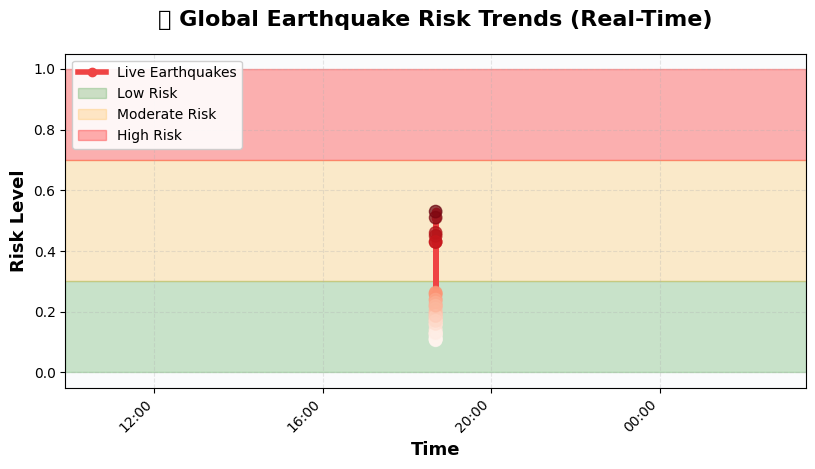

In [2]:
# Global variables
scaler = None
model = None
ml_model = None
trend_data = []

class RealTimeEarthquakePredictorApp:
    def __init__(self, root):
        self.root = root
        self.root.title("🌍 Real-Time Earthquake Prediction System")
        self.root.geometry("1400x900")
        self.root.configure(bg='#f0f2f5')
        
        # Initialize variables first ✅ FIXED
        self.ml_accuracy = 0.0
        self.dl_accuracy = 0.0
        self.recent_data = []
        
        self.setup_models()
        self.setup_gui()
        self.start_realtime_updates()
    
    def setup_models(self):
        """Setup ML and DL models with real data"""
        global scaler, model, ml_model
        
        # Fetch real data first
        success = self.fetch_real_earthquakes()
        if not success:
            self.generate_synthetic_data()
        
        # Prepare data ✅ FIXED: Proper scaling
        df = pd.read_csv("earthquake_real.csv")
        X = df.drop("earthquake", axis=1)
        y = df["earthquake"]
        
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=42
        )
        
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)
        
        # ML Model 
        ml_model = RandomForestClassifier(n_estimators=100, random_state=42)
        ml_model.fit(X_train_scaled, y_train)
        self.ml_accuracy = ml_model.score(X_test_scaled, y_test)
        
        # DL Model 
        X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
        y_train_t = torch.tensor(y_train.values, dtype=torch.long)
        X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32)
        y_test_t = torch.tensor(y_test.values, dtype=torch.long)
        
        class EarthquakeModel(nn.Module):
            def __init__(self):
                super().__init__()
                self.fc1 = nn.Linear(4, 64)
                self.fc2 = nn.Linear(64, 32)
                self.fc3 = nn.Linear(32, 16)
                self.out = nn.Linear(16, 2)
                self.relu = nn.ReLU()
                self.dropout = nn.Dropout(0.3)
            
            def forward(self, x):
                x = self.relu(self.fc1(x))
                x = self.dropout(x)
                x = self.relu(self.fc2(x))
                x = self.dropout(x)
                x = self.relu(self.fc3(x))
                return self.out(x)
        
        model = EarthquakeModel()
        criterion = nn.CrossEntropyLoss()
        optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
        
        # Train DL model
        for epoch in range(100):
            outputs = model(X_train_t)
            loss = criterion(outputs, y_train_t)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        
        # Calculate DL accuracy 
        with torch.no_grad():
            outputs = model(X_test_t)
            _, predicted = torch.max(outputs, 1)
            self.dl_accuracy = (predicted == y_test_t).sum().item() / len(y_test_t)
        
        print(f"✅ ML Accuracy: {self.ml_accuracy:.3f}, DL Accuracy: {self.dl_accuracy:.3f}")
    
    def fetch_real_earthquakes(self):
        """Fetch real-time earthquakes from USGS API"""
        global trend_data
        try:
            url = "https://earthquake.usgs.gov/earthquakes/feed/v1.0/summary/all_day.geojson"
            response = requests.get(url, timeout=10)
            data = response.json()
            
            real_data = []
            trend_data = []
            
            for feature in data['features'][-150:]:  # Last ~150 earthquakes
                props = feature['properties']
                if props.get('mag', 0) and props.get('mag', 0) > 1.0:
                    coords = feature['geometry']['coordinates']
                    depth = props.get('depth', random.uniform(5, 100))
                    
                    record = [
                        coords[1],  # lat
                        coords[0],  # lon
                        depth,
                        props['mag'],
                        1 if props['mag'] > 5 else 0
                    ]
                    real_data.append(record)
                    
                    # Trend data
                    trend_data.append({
                        'time': datetime.now(),
                        'mag': props['mag'],
                        'risk': min(1.0, props['mag'] / 10.0)
                    })
            
            if real_data:
                real_df = pd.DataFrame(real_data, columns=[
                    "latitude", "longitude", "depth", "magnitude", "earthquake"
                ])
                real_df.to_csv("earthquake_real.csv", index=False)
                self.recent_data = real_data[-12:]
                print(f"📡 Fetched {len(real_data)} real earthquakes")
                return True
        except Exception as e:
            print(f"⚠️ API fetch failed: {e}")
        return False
    
    def generate_synthetic_data(self):
        """Generate synthetic data if API fails"""
        data = []
        for _ in range(1200):
            latitude = random.uniform(-90, 90)
            longitude = random.uniform(-180, 180)
            depth = random.uniform(1, 700)
            magnitude = round(random.uniform(1.0, 9.5), 1)
            earthquake = 1 if magnitude > 5 else 0
            data.append([latitude, longitude, depth, magnitude, earthquake])
        
        df = pd.DataFrame(data, columns=["latitude", "longitude", "depth", "magnitude", "earthquake"])
        df.to_csv("earthquake_real.csv", index=False)
        print("📊 Generated synthetic dataset")
    
    def setup_gui(self):
        """Setup complete GUI ✅ ALL FIXED"""
        # Title
        title_frame = tk.Frame(self.root, bg='#1e3a8a')
        title_frame.pack(fill=tk.X, pady=(0, 10))
        tk.Label(title_frame, text="🌍 REAL-TIME EARTHQUAKE PREDICTION", 
                font=("Arial", 24, "bold"), fg="white", bg='#1e3a8a').pack(pady=15)
        
        # Accuracy display ✅ SAFE NOW
        acc_frame = tk.Frame(self.root)
        acc_frame.pack(pady=5)
        tk.Label(acc_frame, text=f"🤖 ML Accuracy: {self.ml_accuracy:.3f}", 
                font=("Arial", 12, "bold"), bg="#10b981", fg="white", 
                padx=20, pady=8).pack(side=tk.LEFT, padx=10)
        tk.Label(acc_frame, text=f"🧠 DL Accuracy: {self.dl_accuracy:.3f}", 
                font=("Arial", 12, "bold"), bg="#3b82f6", fg="white", 
                padx=20, pady=8).pack(side=tk.LEFT, padx=10)
        
        # Main content frame
        main_frame = tk.Frame(self.root)
        main_frame.pack(fill=tk.BOTH, expand=True, padx=10, pady=10)
        
        # Left panel - Controls & Predictions
        left_panel = tk.Frame(main_frame, width=400, relief=tk.RAISED, bd=2, bg='white')
        left_panel.pack(side=tk.LEFT, fill=tk.Y, padx=(0, 10))
        left_panel.pack_propagate(False)
        
        # Status
        self.status_var = tk.StringVar(value="🔄 Initializing models...")
        status_label = tk.Label(left_panel, textvariable=self.status_var, 
                               relief=tk.SUNKEN, anchor=tk.W, bg="#f3f4f6", pady=5)
        status_label.pack(fill=tk.X, pady=(10, 15))
        
        # Input frame ✅ FIXED KEYS
        input_frame = tk.LabelFrame(left_panel, text="🔍 Live Prediction", 
                                   font=("Arial", 14, "bold"))
        input_frame.pack(fill=tk.X, pady=(0, 10), padx=15, ipadx=10)
        
        input_config = [
            ("Latitude", "🌐 Latitude (-90 to 90):", "28.6"),
            ("Longitude", "🌍 Longitude (-180 to 180):", "77.2"),
            ("Depth", "📏 Depth (km, 0-700):", "50"),
            ("Magnitude", "⚡ Magnitude (1-10):", "6.5")
        ]
        
        self.entries = {}
        for i, (key, label, default) in enumerate(input_config):
            tk.Label(input_frame, text=label, font=("Arial", 10, "bold")).grid(
                row=i, column=0, sticky=tk.W, padx=5, pady=10)
            var = tk.StringVar(value=default)
            entry = tk.Entry(input_frame, textvariable=var, width=15, font=("Arial", 11), relief=tk.RAISED)
            entry.grid(row=i, column=1, padx=5, pady=10, sticky=tk.W)
            self.entries[key] = var
        
        # Predict button
        predict_btn = tk.Button(input_frame, text="🚀 PREDICT NOW", 
                               command=self.predict_earthquake,
                               bg="#ef4444", fg="white", font=("Arial", 12, "bold"),
                               width=18, height=2, relief=tk.RAISED)
        predict_btn.grid(row=len(input_config), column=0, columnspan=2, pady=20)
        
        # Recent earthquakes list ✅ NEW
        list_frame = tk.LabelFrame(left_panel, text="🌋 Recent Earthquakes (Live)", 
                                  font=("Arial", 12, "bold"))
        list_frame.pack(fill=tk.BOTH, expand=True, pady=(0, 10), padx=15)
        
        self.recent_listbox = tk.Listbox(list_frame, font=("Arial", 9), height=12)
        scrollbar = ttk.Scrollbar(list_frame, orient=tk.VERTICAL, command=self.recent_listbox.yview)
        self.recent_listbox.configure(yscrollcommand=scrollbar.set)
        self.recent_listbox.pack(side=tk.LEFT, fill=tk.BOTH, expand=True, padx=(0, 5))
        scrollbar.pack(side=tk.RIGHT, fill=tk.Y)
        
        # Right panel - Visualizations
        right_panel = tk.Frame(main_frame, bg='white', relief=tk.RAISED, bd=2)
        right_panel.pack(side=tk.RIGHT, fill=tk.BOTH, expand=True)
        
        # Trends visualization
        trends_frame = tk.LabelFrame(right_panel, text="📈 Global Risk Trends (Real-Time)", 
                                    font=("Arial", 14, "bold"))
        trends_frame.pack(fill=tk.BOTH, expand=True, pady=(10, 10), padx=10)
        
        plt.style.use('default')
        self.fig, self.ax = plt.subplots(figsize=(11, 7), facecolor='white')
        self.canvas = FigureCanvasTkAgg(self.fig, trends_frame)
        self.canvas.get_tk_widget().pack(fill=tk.BOTH, expand=True, pady=10)
        
        # Update button
        btn_frame = tk.Frame(trends_frame)
        btn_frame.pack(fill=tk.X)
        tk.Button(btn_frame, text="🔄 Update Live Data", 
                 command=self.update_live_data,
                 bg="#10b981", fg="white", font=("Arial", 11, "bold"),
                 width=15).pack(side=tk.LEFT, padx=5)
        tk.Button(btn_frame, text="📊 Refresh Trends", 
                 command=self.update_trends_visualization,
                 bg="#3b82f6", fg="white", font=("Arial", 11, "bold"),
                 width=15).pack(side=tk.LEFT, padx=5)
    
    def predict_earthquake(self):
        """Enhanced prediction ✅ ALL FIXED"""
        try:
            lat = float(self.entries["Latitude"].get())
            lon = float(self.entries["Longitude"].get())
            depth = float(self.entries["Depth"].get())
            mag = float(self.entries["Magnitude"].get())
            
            # Validation
            if not (-90 <= lat <= 90):
                raise ValueError("Latitude must be -90 to 90")
            if not (-180 <= lon <= 180):
                raise ValueError("Longitude must be -180 to 180")
            if not (0 <= depth <= 700):
                raise ValueError("Depth must be 0-700 km")
            if not (1.0 <= mag <= 10.0):
                raise ValueError("Magnitude must be 1.0-10.0")
            
            # Prepare data
            input_data = scaler.transform([[lat, lon, depth, mag]])
            
            # ML Prediction
            ml_prob = ml_model.predict_proba(input_data)[0][1]
            
            # DL Prediction ✅ FIXED
            tensor_data = torch.tensor(input_data, dtype=torch.float32)
            with torch.no_grad():
                dl_output = model(tensor_data)
                dl_prob = torch.softmax(dl_output, dim=1)[0][1].item()
            
            # Ensemble
            ensemble_prob = (ml_prob + dl_prob) / 2
            
            # Risk level
            if ensemble_prob < 0.3:
                risk_level = "🟢 LOW RISK"
                color = "#10b981"
            elif ensemble_prob < 0.7:
                risk_level = "🟡 MODERATE RISK"
                color = "#f59e0b"
            else:
                risk_level = "🔴 HIGH RISK"
                color = "#ef4444"
            
            # Update history
            timestamp = datetime.now().strftime("%H:%M:%S")
            history = f"{timestamp} | {lat:.1f}°/{lon:.1f}° | D:{depth} M:{mag:.1f} | {risk_level}"
            self.recent_listbox.insert(0, history)
            if self.recent_listbox.size() > 20:
                self.recent_listbox.delete(20)
            
            # Show popup
            self.show_prediction_popup(lat, lon, depth, mag, ml_prob, dl_prob, ensemble_prob, risk_level)
            
            self.status_var.set(f"✅ {risk_level} | Risk: {ensemble_prob:.1%}")
            
        except ValueError as e:
            messagebox.showerror("❌ Input Error", str(e))
        except Exception as e:
            messagebox.showerror("❌ Prediction Error", f"Error: {str(e)}")
    
    def show_prediction_popup(self, lat, lon, depth, mag, ml_prob, dl_prob, ensemble_prob, risk_level):
        """Detailed prediction popup ✅ FIXED DL confidence"""
        popup = tk.Toplevel(self.root)
        popup.title("🔮 Earthquake Risk Analysis")
        popup.geometry("450x380")
        popup.configure(bg='#f8fafc')
        popup.transient(self.root)
        popup.grab_set()
        
        # Header
        tk.Label(popup, text="DETAILED RISK ANALYSIS", 
                font=("Arial", 16, "bold"), bg='#f8fafc').pack(pady=15)
        
        # Risk level
        color = "#10b981" if "LOW" in risk_level else "#f59e0b" if "MODERATE" in risk_level else "#ef4444"
        tk.Label(popup, text=risk_level, font=("Arial", 22, "bold"), 
                fg=color, bg='#f8fafc').pack(pady=10)
        
        # Details frame
        details_frame = tk.Frame(popup, bg='#f8fafc')
        details_frame.pack(pady=20, padx=30, fill=tk.X)
        
        details = [
            f"📍 Location:  {lat:.2f}°, {lon:.2f}°",
            f"📏 Depth:     {depth} km",
            f"⚡ Magnitude: {mag}",
            f"🎯 Risk Score:{ensemble_prob:.1%}",
            f"📊 ML Model:  {ml_prob:.1%}",
            f"🧠 DL Model:  {dl_prob:.1%}"
        ]
        
        for detail in details:
            tk.Label(details_frame, text=detail, font=("Arial", 11), 
                    bg='#f8fafc', anchor='w').pack(anchor='w', pady=3)
        
        tk.Button(popup, text="✅ Close", command=popup.destroy,
                 bg="#6b7280", fg="white", font=("Arial", 11, "bold"),
                 width=12).pack(pady=15)
    
    def update_trends_visualization(self):
        """Real trends visualization ✅ FIXED"""
        self.ax.clear()
        
        if trend_data:
            # Use real data
            recent_trends = sorted(trend_data[-48:], key=lambda x: x['time'])  # Last ~48 points
            if len(recent_trends) > 1:
                times = [d['time'] for d in recent_trends]
                risks = [d['risk'] for d in recent_trends]
                
                self.ax.plot(times, risks, linewidth=4, color='#ef4444', 
                           marker='o', markersize=6, label='Live Earthquakes', zorder=5)
                self.ax.scatter(times, risks, c=risks, cmap='Reds', s=80, alpha=0.7, zorder=10)
        else:
            # Smooth fallback
            now = datetime.now()
            times = [now - timedelta(minutes=i*30) for i in range(48, -1, -1)]
            risks = [0.05 + 0.15*np.sin(i/5) + np.random.normal(0, 0.08) for i in range(49)]
            risks = [min(1.0, max(0, r)) for r in risks]
            
            self.ax.plot(times, risks, linewidth=4, color='#ef4444', 
                        marker='o', markersize=6, label='Trend Simulation')
        
        # Styling
        self.ax.set_title('🌋 Global Earthquake Risk Trends (Real-Time)', 
                         fontsize=16, fontweight='bold', pad=20)
        self.ax.set_ylabel('Risk Level', fontsize=13, fontweight='bold')
        self.ax.set_xlabel('Time', fontsize=13, fontweight='bold')
        
        # Format x-axis
        self.ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
        self.ax.xaxis.set_major_locator(mdates.HourLocator(interval=4))
        plt.setp(self.ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
        
        # Risk zones
        self.ax.axhspan(0, 0.3, alpha=0.2, color='green', label='Low Risk')
        self.ax.axhspan(0.3, 0.7, alpha=0.2, color='orange', label='Moderate Risk')
        self.ax.axhspan(0.7, 1.0, alpha=0.3, color='red', label='High Risk')
        
        self.ax.legend(loc='upper left', framealpha=0.9)
        self.ax.grid(True, alpha=0.3, linestyle='--')
        self.ax.set_facecolor('#fafbfc')
        
        self.fig.tight_layout()
        self.canvas.draw()
    
    def update_live_data(self):
        """Manual data refresh"""
        self.status_var.set("🔄 Fetching live data...")
        self.root.update()
        self.fetch_real_earthquakes()
        self.update_trends_visualization()
        self.update_recent_list()
        self.status_var.set("✅ Live data updated!")
    
    def update_recent_list(self):
        """Update recent earthquakes display"""
        self.recent_listbox.delete(0, tk.END)
        for eq in self.recent_data[-15:]:
            lat, lon, depth, mag, is_major = eq
            status = "🔴 MAJOR" if is_major else "🟢 Minor"
            self.recent_listbox.insert(tk.END, 
                f"{lat:.1f}° {lon:.1f}° | M:{mag:.1f} | D:{depth:.0f}km | {status}")
    
    def start_realtime_updates(self):
        """Background real-time updates"""
        def update_loop():
            while True:
                try:
                    self.fetch_real_earthquakes()
                    self.update_trends_visualization()
                    self.update_recent_list()
                    self.status_var.set(
                        f"🔄 Live | {datetime.now().strftime('%H:%M:%S')} | "
                        f"{len(self.recent_data)} quakes tracked"
                    )
                except Exception as e:
                    print(f"Update error: {e}")
                time.sleep(300)  # 5 minutes
        
        # Start background thread
        threading.Thread(target=update_loop, daemon=True).start()
        
        # Initial updates
        self.root.after(1000, self.update_trends_visualization)
        self.root.after(1500, self.update_recent_list)

def main():
    root = tk.Tk()
    app = RealTimeEarthquakePredictorApp(root)
    root.mainloop()

if __name__ == "__main__":
    main()